# Explainable AI
melihat perjalanan data masuk ke dalam model kita, jadi ketika dalam proses nya, akan ada banyak kalkulasi dan si X_lime ini memperhatikan kalkulasinya<br>
kenapa dia bisa memprediksi, apa saja yg mempengaruhi prediksi dan seterusnya ini lah LIME<br>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# pip install lime shap
from lime.lime_tabular import LimeTabularExplainer
import shap
import warnings
warnings.filterwarnings('ignore')   #biar gada peringatan

c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
iris = load_iris()
X = iris['data']
y = iris['target']
feature_names = iris['feature_names']
class_name = iris['target_names']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
scaler = MinMaxScaler()
X_train_std = scaler.fit_transform(X_train)     # ini masih dalam bentuk numpy
X_test_std = scaler.transform(X_test)           # harus di ubah ke bentuk tensor double list [[ ]]

In [7]:
torch.manual_seed(42)
device = torch.device('cpu')    #pake CPU kita reall

In [8]:
Xtr_t = torch.tensor(X_train_std, dtype=torch.float32).to(device)       # ini pengubahan nya
ytr_t = torch.tensor(y_train, dtype=torch.long).to(device)              # cari sendiri artinya long
Xte_t = torch.tensor(X_test_std, dtype=torch.float32).to(device)
yte_t = torch.tensor(y_test, dtype=torch.long).to(device)

In [9]:
model = nn.Sequential(          # membuat neural network
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 3),           #lanjut di menit 40
).to(device)

In [10]:
# Loss Function
criterion = nn.CrossEntropyLoss()                       # sama seperti MSE, MAE
optimizer = optim.Adam(model.parameters(), lr=1e-3)     # 0.01
epochs = 300

In [11]:
for epoch in range(epochs):         # ini nge train model
    model.train()
    optimizer.zero_grad()
    logits = model(Xtr_t)
    loss = criterion(logits, ytr_t)
    loss.backward()
    optimizer.step()

In [12]:
model.eval()                        # ini evaluation 
with torch.no_grad():               # simple nya kita ga belajar lagi
    logits_te = model(Xte_t)
    ypred = logits_te.argmax(dim=1).cpu().numpy()

In [13]:
from sklearn.metrics import accuracy_score

print(f'acc score: {accuracy_score(y_test, ypred)}')
print(classification_report(y_test, ypred, target_names=class_name))

acc score: 0.9333333333333333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



# XAI 
Wrapper Predict

In [14]:
softmax = nn.Softmax(dim=1)     #softmax sebuah function ketika dimasukan input, diakan memberikan probabilitas
def predict_proba_numpy(X_numpy):   # fungsi probabilitas untuk memilih kelas mana yg di predksi model
    model.eval()
    Xs = scaler.transform(X_numpy)
    Xt = torch.tensor(Xs, dtype=torch.float32).to(device)
    with torch.no_grad():
        probs = softmax(model(Xt)).cpu().numpy()

    return probs

# Lime

In [16]:
explainer_lime = LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=list(class_name),
    discretize_continuous=True,
    mode='classification'
)


In [17]:
idx = 5
x0 = X_test[idx]
x0_std = X_test_std[idx]
y0 = y_test[idx]

In [19]:
def predict_proba_raw(X_raw):
    return predict_proba_numpy(X_raw)


In [20]:
lime_explain = explainer_lime.explain_instance(
    data_row=x0,
    predict_fn=predict_proba_raw,
    num_features=4
)

In [21]:
print(f'\n[LIME] Explaintation for instance idx = {idx}')
print(f'True class: {class_name[y0]}')
print(f'Pred proba: {predict_proba_raw(x0.reshape(1, -1))[0]}')
lime_explain.as_list()


[LIME] Explaintation for instance idx = 5
True class: versicolor
Pred proba: [0.00657938 0.5030665  0.49035415]


[('4.25 < petal length (cm) <= 5.10', 0.07817421803980103),
 ('1.30 < petal width (cm) <= 1.80', 0.06310650147058822),
 ('5.75 < sepal length (cm) <= 6.40', 0.033970325895879415),
 ('3.00 < sepal width (cm) <= 3.32', -0.010503841647429358)]

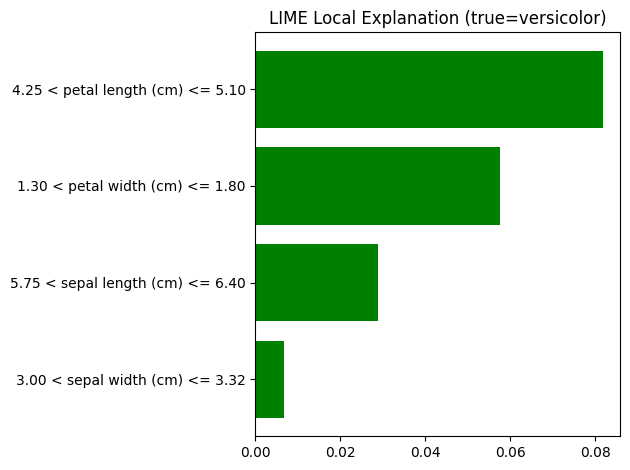

In [ ]:
fig_lime = lime_explain.as_pyplot_figure()
plt.title(f"LIME Local Explanation (true={class_name[y0]})")
plt.tight_layout()
plt.savefig("lime_iris_instance.png", dpi=140)
plt.show()

# Shap

In [22]:
rng = np.random.default_rng(42)
m = min(50, X_train.shape[0])                 # mis. 50 baris
bg_idx = rng.choice(X_train.shape[0], size=m, replace=False)  # ← sample dari JUMLAH BARIS
background = X_train[bg_idx]

In [23]:
# Pilih beberapa titik background (wajib kecil agar cepat)
explainer_shap = shap.KernelExplainer(predict_proba_raw, background)

In [24]:
# Jelaskan 1 instance (x0)
shap_values_x0 = explainer_shap.shap_values(x0.reshape(1, -1), nsamples=300)

100%|██████████| 1/1 [00:00<00:00,  3.27it/s]


In [25]:
print("\n[SHAP] Per-class shap values for the same instance:")
sv2d = np.asarray(shap_values_x0)        # pastikan ndarray (4,3)
for k, cname in enumerate(class_name):
    vals = sv2d[:, k]                    # <-- ambil kolom kelas -> 4 angka (1/ftr)
    pairs = dict(zip(feature_names, np.round(vals, 3)))
    print(f"  Class={cname} | SHAP per-feature: {pairs}")


[SHAP] Per-class shap values for the same instance:
  Class=setosa | SHAP per-feature: {'sepal length (cm)': array([-0.075,  0.02 ,  0.055])}
  Class=versicolor | SHAP per-feature: {'sepal length (cm)': array([-0.001,  0.012, -0.01 ])}
  Class=virginica | SHAP per-feature: {'sepal length (cm)': array([-0.14 ,  0.088,  0.052])}


### Visualisasi Shap

In [ ]:
# belum ditemukan error nya. Aku tunda dulu debug nya hehe
# pastikan bentuknya 2D (4 fitur x 3 kelas)
sv2d = np.asarray(shap_values_x0)        # -> (4, 3)
print("shap_values_x0 shape:", sv2d.shape)

# kelas terprediksi
probs0 = predict_proba_raw(x0.reshape(1,-1))[0]
pred_class = int(np.argmax(probs0))

# vektor kontribusi 4 fitur untuk kelas terprediksi
sv = sv2d[:, pred_class]                 # <-- ambil kolom kelas
local_vals = np.abs(sv)
order = np.argsort(local_vals)[::-1]

# bar chart lokal
plt.figure()
plt.bar(range(len(feature_names)), local_vals[order])
plt.xticks(range(len(feature_names)), np.array(feature_names)[order], rotation=45, ha='right')
plt.title(f"Local SHAP | Instance → {class_name[pred_class]}")
plt.tight_layout(); plt.savefig("shap_local_bar.png", dpi=140)
plt.show()

shap.initjs()
fp = shap.force_plot(
    explainer_shap.expected_value[pred_class],  # expected value utk kelas prediksi
    sv,                                         # kontribusi fitur (arah + besar)
    x0, feature_names=feature_names
)
shap.save_html("shap_force_instance.html", fp)
print("Saved:", "shap_local_bar.png", "shap_force_instance.html")

shap_values_x0 shape: (1, 4, 3)


IndexError: index 2 is out of bounds for axis 0 with size 1

<Figure size 1200x800 with 0 Axes>

shap_values_x0 fixed shape: (3, 4, 1)


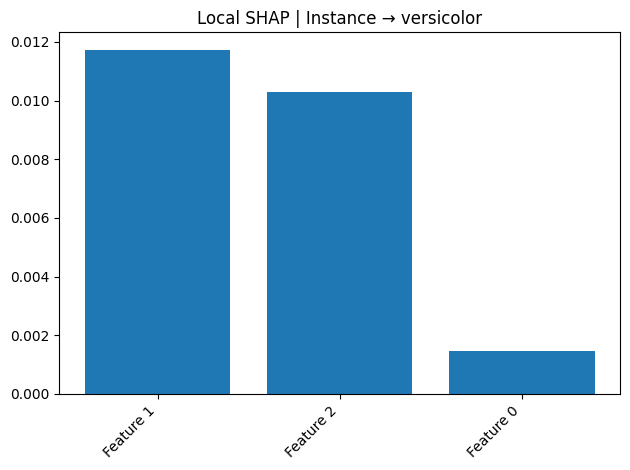

In [ ]:
# by t42

# pastikan bentuk shap_values_x0 jadi 2D: (n_fitur, n_kelas)
sv2d = np.atleast_2d(shap_values_x0)
if sv2d.shape[0] == 1 and sv2d.shape[1] != 1:
    # kalau kebalik, transpose
    sv2d = sv2d.T
print("shap_values_x0 fixed shape:", sv2d.shape)

# kelas terprediksi
probs0 = predict_proba_raw(x0.reshape(1, -1))[0]
pred_class = int(np.argmax(probs0))

# ambil kolom kelas terprediksi
sv = sv2d[:, pred_class]
local_vals = np.abs(sv).flatten()

# urutan fitur dari kontribusi terbesar → terkecil
order = np.argsort(local_vals)[::-1]

# buat feature_names kalau belum ada atau jumlahnya beda
if 'feature_names' not in locals() or len(feature_names) != len(local_vals):
    feature_names = [f"Feature {i}" for i in range(len(local_vals))]

# plotting
plt.figure()
plt.bar(range(len(local_vals)), local_vals[order])
plt.xticks(range(len(local_vals)), np.array(feature_names)[order], rotation=45, ha='right')
plt.title(f"Local SHAP | Instance → {class_name[pred_class]}")
plt.tight_layout()
plt.savefig("shap_local_bar.png", dpi=140)
plt.show()

100%|██████████| 30/30 [00:01<00:00, 17.32it/s]


subset SHAP shape: (30, 4, 3)


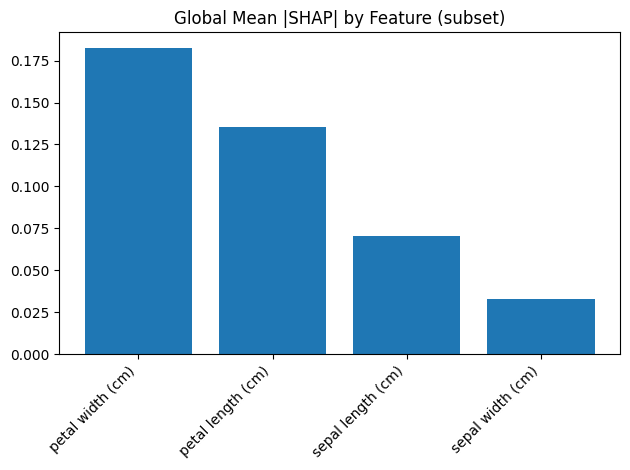

Saved: shap_global_bar.png


In [ ]:
# hitung SHAP untuk subset test biar cepat
subset = X_test[:40]
sv_sub = np.asarray(explainer_shap.shap_values(subset, nsamples=200))  # (N, F, C)
print("subset SHAP shape:", sv_sub.shape)

# kelas prediksi tiap sampel
preds = np.argmax(predict_proba_raw(subset), axis=1)

# rata-rata kontribusi absolut per fitur mengikuti kelas prediksi masing-masing sampel
mean_abs = np.mean([np.abs(sv_sub[i, :, preds[i]]) for i in range(subset.shape[0])], axis=0)

order_g = np.argsort(mean_abs)[::-1]
plt.figure()
plt.bar(range(len(feature_names)), mean_abs[order_g])
plt.xticks(range(len(feature_names)), np.array(feature_names)[order_g], rotation=45, ha='right')
plt.title("Global Mean |SHAP| by Feature (subset)")
plt.tight_layout(); plt.savefig("shap_global_bar.png", dpi=140)
plt.show()

print("Saved:", "shap_global_bar.png")